[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_9_Exercises.ipynb)

# Simple Linear Regression Preliminaries: Exercises

---

## Overview

These exercises give you hands-on practice with the core concepts from the five 17_0 Preliminaries notebooks. All exercises (except the brief Anscombe check in Exercise 2) use the **restaurant tips dataset** built into seaborn: 244 restaurant checks, each recording the total bill amount and the tip left by the customer.

| Exercise | Concepts | Source Notebook |
|---|---|---|
| 1 | Mean as baseline, TSS, variance, standard deviation | 17_0_1 |
| 2 | Scatterplots, summary stats vs. shape | 17_0_2 |
| 3 | Covariance and unit dependence | 17_0_3 |
| 4 | Pearson's r and unit invariance | 17_0_3 |
| 5 | Residuals and the cancellation trap | 17_0_4 |
| 6 | Optimal slope, RSS, and R² | 17_0_5 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Restaurant tips dataset (built into seaborn)
tips = sns.load_dataset('tips').dropna()
x = tips['total_bill'].to_numpy()   # total bill amount ($)
y = tips['tip'].to_numpy()          # tip amount ($)

x_mean = np.mean(x)
y_mean = np.mean(y)

print(f'Number of restaurant bills: {len(x)}')
print(f'Bill range: ${x.min():.2f} – ${x.max():.2f}')
print(f'Tip range:  ${y.min():.2f} – ${y.max():.2f}')
print(f'Mean bill: ${x_mean:.2f}    Mean tip: ${y_mean:.2f}')

Number of restaurant bills: 244
Bill range: $3.07 – $50.81
Tip range:  $1.00 – $10.00
Mean bill: $19.79    Mean tip: $3.00


---

## Exercise 1: The Baseline Model — Mean, TSS, and Standard Deviation

Before fitting any regression model we need to understand the **baseline model** — the model that ignores the bill entirely and always guesses the mean tip.

For Tasks 1a–1c use only `np.sum`, `np.sqrt`, `len`, and basic arithmetic. Do **not** call `np.mean`, `np.var`, or `np.std` until the verification steps.

In [2]:
# ── Task 1a: Compute the mean tip ────────────────────────────────────────────
# Using np.sum() and len() (not np.mean), compute the mean tip amount.
# Store the result in mean_tip and print it with a label.

# TODO: your code here


# Uncomment to verify once you have an answer:
# print(f'NumPy check: ${np.mean(y):.4f}')

In [3]:
# @title Execute to see solution

print('''
mean_tip = np.sum(y) / len(y)
print(f"Mean tip: ${mean_tip:.4f}")
''')

mean_tip = np.sum(y) / len(y)
print(f'Mean tip: ${mean_tip:.4f}')
print(f'NumPy check: ${np.mean(y):.4f}')


mean_tip = np.sum(y) / len(y)
print(f"Mean tip: ${mean_tip:.4f}")

Mean tip: $2.9983
NumPy check: $2.9983


**Task 1b:** Compute the Total Sum of Squares (TSS).

$$\text{TSS} = \sum_{i=1}^{N}(y_i - \bar{y})^2$$

In [4]:
# ── Task 1b: Compute TSS from scratch ────────────────────────────────────────
# Store the result in tss.

# TODO: your code here

In [5]:
# @title Execute to see solution

print('''
deviations = y - mean_tip
tss = np.sum(deviations ** 2)
print(f"TSS: {tss:,.2f} dollars squared")
''')

deviations = y - mean_tip
tss = np.sum(deviations ** 2)
print(f'TSS: {tss:,.2f} dollars²')


deviations = y - mean_tip
tss = np.sum(deviations ** 2)
print(f"TSS: {tss:,.2f} dollars squared")

TSS: 465.21 dollars²


**Task 1c:** Compute variance and standard deviation from TSS.

$$\text{Variance} = \frac{\text{TSS}}{N} \qquad \text{Standard Deviation} = \sqrt{\text{Variance}}$$

In [6]:
# ── Task 1c: Variance and standard deviation ──────────────────────────────────
# Store results in variance_tip and std_tip.
# Verify both with np.var(y) and np.std(y).

# TODO: your code here

In [7]:
# @title Execute to see solution

print('''
N = len(y)
variance_tip = tss / N
std_tip = np.sqrt(variance_tip)

print(f"Variance:           {variance_tip:.4f} dollars squared")
print(f"Standard deviation: ${std_tip:.4f}")
print(f"np.var check:  {np.var(y):.4f}")
print(f"np.std check:  {np.std(y):.4f}")
''')

N = len(y)
variance_tip = tss / N
std_tip = np.sqrt(variance_tip)

print(f'Variance:           {variance_tip:.4f} dollars²')
print(f'Standard deviation: ${std_tip:.4f}')
print(f'np.var check:       {np.var(y):.4f}')
print(f'np.std check:       {np.std(y):.4f}')


N = len(y)
variance_tip = tss / N
std_tip = np.sqrt(variance_tip)

print(f"Variance:           {variance_tip:.4f} dollars squared")
print(f"Standard deviation: ${std_tip:.4f}")
print(f"np.var check:  {np.var(y):.4f}")
print(f"np.std check:  {np.std(y):.4f}")

Variance:           1.9066 dollars²
Standard deviation: $1.3808
np.var check:       1.9066
np.std check:       1.3808


**Question 1d (written, no code):** Based on your results, complete this sentence in your own words:

> *"If we had to guess a tip amount with no other information, our best single guess would be **\$\_\_\_** and we would typically be off by about **\$\_\_\_**."*

Is the typical error large or small relative to the mean tip? What does this suggest about whether tips are predictable from the mean alone?

---

## Exercise 2: Visualizing Associations

The central lesson of Notebook 17_0_2: summary statistics are blind to shape. This exercise has two parts — a scatterplot of our tips data, then a quick hands-on confirmation of Anscombe's Quartet.

In [8]:
# ── Task 2a: Scatterplot of total_bill vs tip ─────────────────────────────────
# Include axis labels (with units) and a descriptive title.

# TODO: your code here


fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=30, alpha=0.6, color='steelblue', edgecolor='white')
ax.set_xlabel('Total bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_title('Restaurant bills: total bill vs. tip amount')
plt.show()



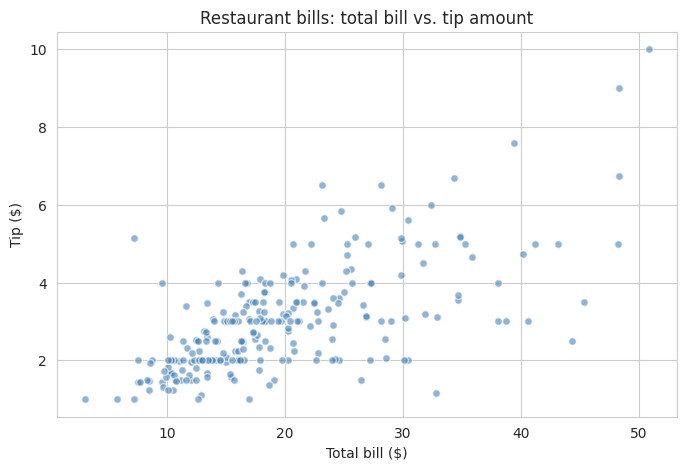

In [9]:
# @title Execute to see solution

print('''
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=30, alpha=0.6, color='steelblue', edgecolor='white')
ax.set_xlabel('Total bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_title('Restaurant bills: total bill vs. tip amount')
plt.show()
''')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=30, alpha=0.6, color='steelblue', edgecolor='white')
ax.set_xlabel('Total bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_title('Restaurant bills: total bill vs. tip amount')
plt.show()

**Task 2b — Anscombe's Quartet (verification):** Notebook 17_0_2 claimed all four Anscombe datasets have nearly identical summary statistics. Verify this yourself, then plot all four to see how different they actually look.

In [10]:
# ── Task 2b: Verify Anscombe's Quartet ───────────────────────────────────────
anscombe = sns.load_dataset('anscombe')

# Step 1: Use groupby to compute mean_x, mean_y, var_x, var_y for each dataset.
# Round to 2 decimal places.

# TODO: your code here (groupby + agg)


# Step 2: Create a 2×2 grid of scatterplots, one per dataset.

# TODO: your code here


# Step 1 — summary stats
summary = anscombe.groupby('dataset').agg(
    mean_x=('x', 'mean'),
    mean_y=('y', 'mean'),
    var_x=('x',  'var'),
    var_y=('y',  'var'),
).round(2)
print(summary)

# Step 2 — 2x2 scatterplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, label in zip(axes.flat, ["I", "II", "III", "IV"]):
    subset = anscombe[anscombe["dataset"] == label]
    ax.scatter(subset["x"], subset["y"], s=60, color="steelblue", edgecolor="white")
    ax.set_title(f"Dataset {label}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.suptitle("Anscombe's Quartet — same stats, completely different shapes", fontsize=12)
plt.tight_layout()
plt.show()

         mean_x  mean_y  var_x  var_y
dataset                              
I           9.0     7.5   11.0   4.13
II          9.0     7.5   11.0   4.13
III         9.0     7.5   11.0   4.12
IV          9.0     7.5   11.0   4.12


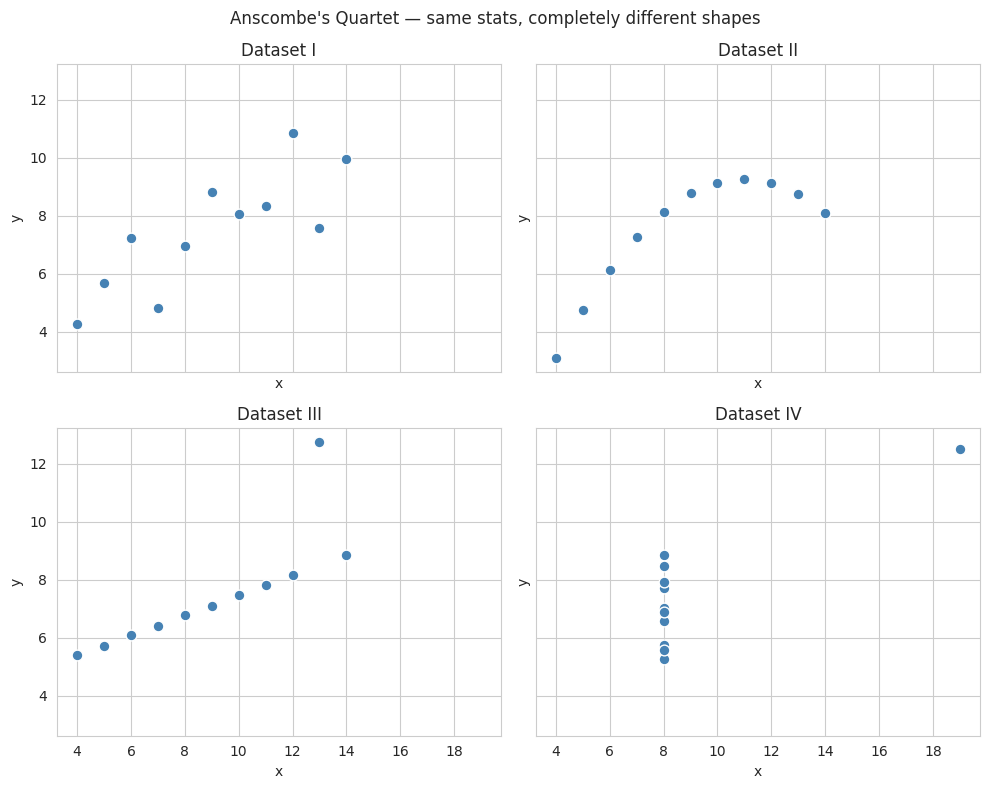

In [11]:
# @title Execute to see solution

print('''
# Step 1 — summary stats
summary = anscombe.groupby('dataset').agg(
    mean_x=('x', 'mean'),
    mean_y=('y', 'mean'),
    var_x=('x',  'var'),
    var_y=('y',  'var'),
).round(2)
print(summary)

# Step 2 — 2x2 scatterplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, label in zip(axes.flat, ["I", "II", "III", "IV"]):
    subset = anscombe[anscombe["dataset"] == label]
    ax.scatter(subset["x"], subset["y"], s=60, color="steelblue", edgecolor="white")
    ax.set_title(f"Dataset {label}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.suptitle("Anscombe\'s Quartet — same stats, completely different shapes", fontsize=12)
plt.tight_layout()
plt.show()
''')

summary = anscombe.groupby('dataset').agg(
    mean_x=('x', 'mean'),
    mean_y=('y', 'mean'),
    var_x=('x',  'var'),
    var_y=('y',  'var'),
).round(2)
print(summary)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, label in zip(axes.flat, ['I', 'II', 'III', 'IV']):
    subset = anscombe[anscombe['dataset'] == label]
    ax.scatter(subset['x'], subset['y'], s=60, color='steelblue', edgecolor='white')
    ax.set_title(f'Dataset {label}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
fig.suptitle("Anscombe's Quartet — same stats, completely different shapes", fontsize=12)
plt.tight_layout()
plt.show()

**Question 2c (written, no code):**

1. Back on the **tips scatterplot** (Task 2a): does the relationship look positive, negative, or near-zero? Roughly linear? Any obvious outliers or high-leverage points?

2. Looking at the **Anscombe table**: confirm that all four datasets share nearly the same mean and variance. Now look at the four plots — which dataset would a linear model fit poorly? Why?

3. In Anscombe Dataset IV, ten points share the same x-value. The single point at x ≈ 19 is a **high-leverage** point. What would happen to the slope of a fitted line if that one point were removed?

---

## Exercise 3: Covariance from Scratch

Implement covariance to quantify the direction of the association you saw in Exercise 2.

$$\text{Cov}(x, y) = \frac{1}{N}\sum_{i=1}^{N}(x_i - \bar{x})(y_i - \bar{y})$$

Use only `np.mean`, `**`, and `np.sum` — do **not** call `np.cov`.

In [12]:
# ── Task 3a: Compute covariance from scratch ──────────────────────────────────
# Store deviations in x_dev and y_dev, and the result in cov_xy.

# TODO: your code here


# Note: np.cov uses N-1 (sample covariance) so it will differ slightly:
# print(f'np.cov check (N-1): {np.cov(x, y)[0, 1]:.4f}')

In [13]:
# @title Execute to see solution

print('''
x_dev  = x - x_mean
y_dev  = y - y_mean
cov_xy = np.mean(x_dev * y_dev)

print(f"Covariance: {cov_xy:.4f}  (units: dollar x dollar)")
print(f"np.cov check (N-1): {np.cov(x, y)[0, 1]:.4f}")
''')

x_dev  = x - x_mean
y_dev  = y - y_mean
cov_xy = np.mean(x_dev * y_dev)

print(f'Covariance: {cov_xy:.4f}  (units: dollar × dollar)')
print(f'np.cov check (N-1): {np.cov(x, y)[0, 1]:.4f}')


x_dev  = x - x_mean
y_dev  = y - y_mean
cov_xy = np.mean(x_dev * y_dev)

print(f"Covariance: {cov_xy:.4f}  (units: dollar x dollar)")
print(f"np.cov check (N-1): {np.cov(x, y)[0, 1]:.4f}")

Covariance: 8.2894  (units: dollar × dollar)
np.cov check (N-1): 8.3235


**Task 3b — Unit sensitivity:** The bill amounts are in dollars. What happens if we record them in **cents** (multiply by 100)?

*Predict the ratio before running the code.*

In [14]:
# ── Task 3b: Recompute covariance with bills in cents ─────────────────────────
# x_cents = x * 100
# Compute cov_xy_cents and compare to cov_xy.

# TODO: your code here

In [15]:
# @title Execute to see solution

print('''
x_cents     = x * 100
x_cents_dev = x_cents - np.mean(x_cents)
cov_xy_cents = np.mean(x_cents_dev * y_dev)

print(f"Covariance (dollars): {cov_xy:.4f}")
print(f"Covariance (cents):   {cov_xy_cents:.4f}")
print(f"Ratio: {cov_xy_cents / cov_xy:.0f}x  (100x larger when x was scaled by 100)")
''')

x_cents      = x * 100
x_cents_dev  = x_cents - np.mean(x_cents)
cov_xy_cents = np.mean(x_cents_dev * y_dev)

print(f'Covariance (dollars): {cov_xy:.4f}')
print(f'Covariance (cents):   {cov_xy_cents:.4f}')
print(f'Ratio: {cov_xy_cents / cov_xy:.0f}x  (100x larger when x was scaled by 100)')


x_cents     = x * 100
x_cents_dev = x_cents - np.mean(x_cents)
cov_xy_cents = np.mean(x_cents_dev * y_dev)

print(f"Covariance (dollars): {cov_xy:.4f}")
print(f"Covariance (cents):   {cov_xy_cents:.4f}")
print(f"Ratio: {cov_xy_cents / cov_xy:.0f}x  (100x larger when x was scaled by 100)")

Covariance (dollars): 8.2894
Covariance (cents):   828.9389
Ratio: 100x  (100x larger when x was scaled by 100)


---

## Exercise 4: Pearson's r from Scratch

Fix covariance's unit problem by standardizing it:

$$r = \frac{\text{Cov}(x, y)}{\sigma_x \cdot \sigma_y}$$

Then verify that converting bills to cents leaves $r$ unchanged — a property covariance does **not** have.

In [16]:
# ── Task 4: Compute Pearson's r ───────────────────────────────────────────────
# Use the results from Exercise 3 (x_dev, y_dev, cov_xy, x_cents_dev, cov_xy_cents).
#
#   std_x = sqrt(mean(x_dev ** 2))
#   std_y = sqrt(mean(y_dev ** 2))
#   r     = cov_xy / (std_x * std_y)
#
# After computing r:
#   1. Verify against np.corrcoef(x, y)[0, 1]
#   2. Recompute r using x_cents — confirm the value is identical.

# TODO: your code here

In [17]:
# @title Execute to see solution

print('''
std_x = np.sqrt(np.mean(x_dev ** 2))
std_y = np.sqrt(np.mean(y_dev ** 2))
r     = cov_xy / (std_x * std_y)

print(f"Pearson r (dollars):  {r:.6f}")
print(f"np.corrcoef check:    {np.corrcoef(x, y)[0, 1]:.6f}")

# Re-run with cents to confirm unit invariance
std_x_cents = np.sqrt(np.mean(x_cents_dev ** 2))
r_cents     = cov_xy_cents / (std_x_cents * std_y)
print(f"Pearson r (cents):    {r_cents:.6f}  <- identical")
''')

std_x = np.sqrt(np.mean(x_dev ** 2))
std_y = np.sqrt(np.mean(y_dev ** 2))
r     = cov_xy / (std_x * std_y)

print(f"Pearson r (dollars):  {r:.6f}")
print(f"np.corrcoef check:    {np.corrcoef(x, y)[0, 1]:.6f}")

std_x_cents = np.sqrt(np.mean(x_cents_dev ** 2))
r_cents     = cov_xy_cents / (std_x_cents * std_y)
print(f"Pearson r (cents):    {r_cents:.6f}  ← identical")


std_x = np.sqrt(np.mean(x_dev ** 2))
std_y = np.sqrt(np.mean(y_dev ** 2))
r     = cov_xy / (std_x * std_y)

print(f"Pearson r (dollars):  {r:.6f}")
print(f"np.corrcoef check:    {np.corrcoef(x, y)[0, 1]:.6f}")

# Re-run with cents to confirm unit invariance
std_x_cents = np.sqrt(np.mean(x_cents_dev ** 2))
r_cents     = cov_xy_cents / (std_x_cents * std_y)
print(f"Pearson r (cents):    {r_cents:.6f}  <- identical")

Pearson r (dollars):  0.675734
np.corrcoef check:    0.675734
Pearson r (cents):    0.675734  ← identical


**Question 4b (written, no code):**

1. Is $r$ positive or negative? What does this mean in plain English about tipping behavior?
2. Would you call this correlation strong, moderate, or weak?
3. Does $r > 0$ mean that bill amount *causes* people to tip more? Explain briefly.

---

## Exercise 5: Residuals and the Cancellation Trap

Someone proposes the line $\hat{y} = 0.10x + 0.90$ as a tip model ("roughly 10% of the bill, plus 90 cents"). In this exercise you will:

1. Compute and visualize residuals for this guessed line.
2. Show that "residuals sum to zero" is a **useless** quality metric — even a deliberately terrible model can achieve it.

In [18]:
# ── Task 5a: Compute and plot residuals for the guessed line ──────────────────
m_guess = 0.10
b_guess = 0.90

# 1. Compute y_hat_guess and residuals_guess = y - y_hat_guess.
# 2. Print the first 5 rows: bill, actual tip, predicted, residual.
# 3. Print the sum of all residuals.
# 4. Make a residual plot: scatter of (x, residuals_guess) with a horizontal
#    dashed line at 0. Label axes and add a title.

# TODO: your code here


y_hat_guess    = m_guess * x + b_guess
residuals_guess = y - y_hat_guess

print("First 5 residuals:")
for i in range(5):
    print(f"  bill=${x[i]:.2f}  actual=${y[i]:.2f}  "
          f"predicted=${y_hat_guess[i]:.2f}  residual={residuals_guess[i]:+.2f}")
print(f"Sum of residuals: {residuals_guess.sum():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, residuals_guess, s=20, alpha=0.6, color="steelblue", edgecolor="white")
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Residual ($)")
ax.set_title("Residuals for guessed line (m=0.10, b=0.90)")
plt.show()

First 5 residuals:
  bill=$16.99  actual=$1.01  predicted=$2.60  residual=-1.59
  bill=$10.34  actual=$1.66  predicted=$1.93  residual=-0.27
  bill=$21.01  actual=$3.50  predicted=$3.00  residual=+0.50
  bill=$23.68  actual=$3.31  predicted=$3.27  residual=+0.04
  bill=$24.59  actual=$3.61  predicted=$3.36  residual=+0.25
Sum of residuals: 29.2030


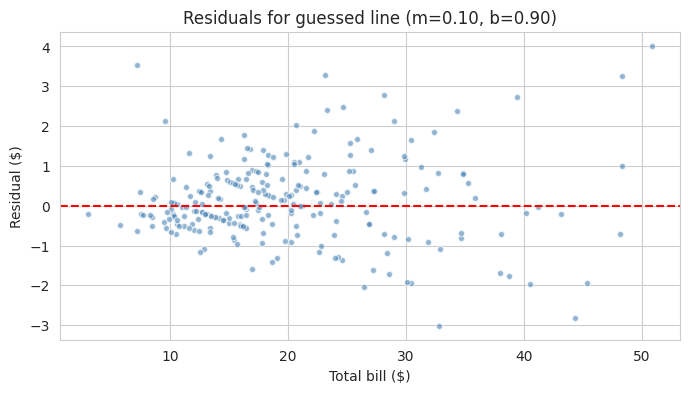

In [19]:
# @title Execute to see solution

print('''
y_hat_guess    = m_guess * x + b_guess
residuals_guess = y - y_hat_guess

print("First 5 residuals:")
for i in range(5):
    print(f"  bill=${x[i]:.2f}  actual=${y[i]:.2f}  "
          f"predicted=${y_hat_guess[i]:.2f}  residual={residuals_guess[i]:+.2f}")
print(f"Sum of residuals: {residuals_guess.sum():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, residuals_guess, s=20, alpha=0.6, color="steelblue", edgecolor="white")
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Total bill ($)")
ax.set_ylabel("Residual ($)")
ax.set_title("Residuals for guessed line (m=0.10, b=0.90)")
plt.show()
''')

y_hat_guess     = m_guess * x + b_guess
residuals_guess = y - y_hat_guess

print('First 5 residuals:')
for i in range(5):
    print(f'  bill=${x[i]:.2f}  actual=${y[i]:.2f}  '
          f'predicted=${y_hat_guess[i]:.2f}  residual={residuals_guess[i]:+.2f}')
print(f'Sum of residuals: {residuals_guess.sum():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, residuals_guess, s=20, alpha=0.6, color='steelblue', edgecolor='white')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Total bill ($)')
ax.set_ylabel('Residual ($)')
ax.set_title('Residuals for guessed line (m=0.10, b=0.90)')
plt.show()

**Task 5b — The Cancellation Trap:** Recall from Notebook 17_0_4: *any* line that passes through $(\bar{x}, \bar{y})$ has residuals that sum to (essentially) zero — including lines that are completely wrong.

Below we construct a **deliberately terrible** model with a **negative slope** (implying bigger bills produce *smaller* tips), adjusted only so that it passes through $(\bar{x}, \bar{y})$. Verify that its residuals still sum to zero — then compare its RSS to the guessed line to show that "sum ≈ 0" is meaningless as a quality score.

$$b_{\text{bad}} = \bar{y} - m_{\text{bad}} \cdot \bar{x}$$

In [20]:
# ── Task 5b: A terrible line that still has Σresiduals ≈ 0 ───────────────────
m_bad = -0.08   # negative slope — backwards relationship

# 1. Compute b_bad so the line passes through (x_mean, y_mean).
# 2. Compute residuals_bad for this line.
# 3. Print the sum of residuals_bad (should be ~0).
# 4. Compute RSS for BOTH lines: rss_guess and rss_bad.
#    Which is larger?

# TODO: your code here

In [21]:
# @title Execute to see solution

print('''
m_bad = -0.08
b_bad = y_mean - m_bad * x_mean

y_hat_bad    = m_bad * x + b_bad
residuals_bad = y - y_hat_bad

rss_guess = np.sum(residuals_guess ** 2)
rss_bad   = np.sum(residuals_bad  ** 2)

print(f"Terrible line: tip = {m_bad}*bill + {b_bad:.4f}")
print(f"Sum of residuals (terrible line): {residuals_bad.sum():.2e}   <- ~zero!")
print()
print(f"RSS (guessed line, m=0.10): {rss_guess:.2f}")
print(f"RSS (terrible line, m=-0.08): {rss_bad:.2f}   <- much worse!")
print()
print("Both lines have residuals summing to ~0, but their RSS values are very different.")
print("RSS is the correct quality metric; the raw sum is useless.")
''')

b_bad = y_mean - m_bad * x_mean

y_hat_bad     = m_bad * x + b_bad
residuals_bad = y - y_hat_bad

rss_guess = np.sum(residuals_guess ** 2)
rss_bad   = np.sum(residuals_bad  ** 2)

print(f'Terrible line: tip = {m_bad}*bill + {b_bad:.4f}')
print(f'Sum of residuals (terrible line): {residuals_bad.sum():.2e}   ← ~zero!')
print()
print(f'RSS (guessed line,  m= 0.10): {rss_guess:.2f}')
print(f'RSS (terrible line, m=-0.08): {rss_bad:.2f}   ← much worse!')
print()
print('Both lines have residuals summing to ~0 but their RSS values are very different.')
print('RSS is the correct quality metric; the raw sum is useless.')


m_bad = -0.08
b_bad = y_mean - m_bad * x_mean

y_hat_bad    = m_bad * x + b_bad
residuals_bad = y - y_hat_bad

rss_guess = np.sum(residuals_guess ** 2)
rss_bad   = np.sum(residuals_bad  ** 2)

print(f"Terrible line: tip = {m_bad}*bill + {b_bad:.4f}")
print(f"Sum of residuals (terrible line): {residuals_bad.sum():.2e}   <- ~zero!")
print()
print(f"RSS (guessed line, m=0.10): {rss_guess:.2f}")
print(f"RSS (terrible line, m=-0.08): {rss_bad:.2f}   <- much worse!")
print()
print("Both lines have residuals summing to ~0, but their RSS values are very different.")
print("RSS is the correct quality metric; the raw sum is useless.")

Terrible line: tip = -0.08*bill + 4.5812
Sum of residuals (terrible line): 1.08e-13   ← ~zero!

RSS (guessed line,  m= 0.10): 256.77
RSS (terrible line, m=-0.08): 912.08   ← much worse!

Both lines have residuals summing to ~0 but their RSS values are very different.
RSS is the correct quality metric; the raw sum is useless.


---

## Exercise 6: Optimal Slope, RSS, and R²

The **optimal** regression line (the one that minimizes RSS) has a closed-form solution built entirely from quantities you already have:

$$m^* = r \cdot \frac{\sigma_y}{\sigma_x} \qquad b^* = \bar{y} - m^* \bar{x}$$

Once we have the optimal line's RSS, comparing it to TSS gives us $R^2$:

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}$$

In [22]:
# ── Task 6a: Compute the optimal slope and intercept ─────────────────────────
# Use r, std_y, std_x, y_mean, x_mean from Exercises 3 & 4.
# Store results in m_optimal and b_optimal.

# TODO: your code here

In [23]:
# @title Execute to see solution

print('''
m_optimal = r * (std_y / std_x)
b_optimal = y_mean - m_optimal * x_mean

print(f"Optimal slope:     m* = {m_optimal:.6f}")
print(f"Optimal intercept: b* = {b_optimal:.6f}")
print(f"Line: tip = {m_optimal:.4f} * total_bill + {b_optimal:.4f}")
''')

m_optimal = r * (std_y / std_x)
b_optimal = y_mean - m_optimal * x_mean

print(f'Optimal slope:     m* = {m_optimal:.6f}')
print(f'Optimal intercept: b* = {b_optimal:.6f}')
print(f'Line: tip = {m_optimal:.4f} * total_bill + {b_optimal:.4f}')


m_optimal = r * (std_y / std_x)
b_optimal = y_mean - m_optimal * x_mean

print(f"Optimal slope:     m* = {m_optimal:.6f}")
print(f"Optimal intercept: b* = {b_optimal:.6f}")
print(f"Line: tip = {m_optimal:.4f} * total_bill + {b_optimal:.4f}")

Optimal slope:     m* = 0.105025
Optimal intercept: b* = 0.920270
Line: tip = 0.1050 * total_bill + 0.9203


In [24]:
# ── Task 6b: Compute RSS for the optimal line, then R² ───────────────────────
# 1. Compute y_hat_optimal and rss_optimal.
# 2. Compute r_squared = 1 - rss_optimal / tss.
# 3. Print TSS, rss_optimal, and r_squared.
# 4. Verify the identity R² = r² (holds for simple linear regression).

# TODO: your code here

In [25]:
# @title Execute to see solution

print('''
y_hat_optimal = m_optimal * x + b_optimal
rss_optimal   = np.sum((y - y_hat_optimal) ** 2)
r_squared     = 1 - rss_optimal / tss

print(f"TSS  (baseline):  {tss:>10,.2f}")
print(f"RSS  (optimal):   {rss_optimal:>10,.2f}")
print(f"R²  = 1-RSS/TSS:  {r_squared:>10.4f}")
print()
print(f"Identity check: r² = {r**2:.6f}   R² = {r_squared:.6f}")
''')

y_hat_optimal = m_optimal * x + b_optimal
rss_optimal   = np.sum((y - y_hat_optimal) ** 2)
r_squared     = 1 - rss_optimal / tss

print(f'TSS  (baseline):  {tss:>10,.2f}')
print(f'RSS  (optimal):   {rss_optimal:>10,.2f}')
print(f'R²  = 1-RSS/TSS:  {r_squared:>10.4f}')
print()
print(f'Identity check: r² = {r**2:.6f}   R² = {r_squared:.6f}')


y_hat_optimal = m_optimal * x + b_optimal
rss_optimal   = np.sum((y - y_hat_optimal) ** 2)
r_squared     = 1 - rss_optimal / tss

print(f"TSS  (baseline):  {tss:>10,.2f}")
print(f"RSS  (optimal):   {rss_optimal:>10,.2f}")
print(f"R²  = 1-RSS/TSS:  {r_squared:>10.4f}")
print()
print(f"Identity check: r² = {r**2:.6f}   R² = {r_squared:.6f}")

TSS  (baseline):      465.21
RSS  (optimal):       252.79
R²  = 1-RSS/TSS:      0.4566

Identity check: r² = 0.456617   R² = 0.456617


**Task 6c — Verify with scikit-learn:** Confirm that `LinearRegression` arrives at the same slope, intercept, and R².

In [26]:
# ── Task 6c: Verify with sklearn ─────────────────────────────────────────────
from sklearn.linear_model import LinearRegression

# sklearn expects a 2-D X. Use x.reshape(-1, 1).
# Compare model.coef_[0], model.intercept_, model.score(X, y)
# to m_optimal, b_optimal, r_squared.

# TODO: your code here

In [27]:
# @title Execute to see solution

print('''
from sklearn.linear_model import LinearRegression

X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)

print(f"Our slope:         {m_optimal:.6f}")
print(f"sklearn slope:     {model.coef_[0]:.6f}")
print()
print(f"Our intercept:     {b_optimal:.6f}")
print(f"sklearn intercept: {model.intercept_:.6f}")
print()
print(f"Our R^2:           {r_squared:.6f}")
print(f"sklearn R^2:       {model.score(X, y):.6f}")
''')

from sklearn.linear_model import LinearRegression

X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)

print(f'Our slope:         {m_optimal:.6f}')
print(f'sklearn slope:     {model.coef_[0]:.6f}')
print()
print(f'Our intercept:     {b_optimal:.6f}')
print(f'sklearn intercept: {model.intercept_:.6f}')
print()
print(f'Our R²:           {r_squared:.6f}')
print(f'sklearn R²:       {model.score(X, y):.6f}')


from sklearn.linear_model import LinearRegression

X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)

print(f"Our slope:         {m_optimal:.6f}")
print(f"sklearn slope:     {model.coef_[0]:.6f}")
print()
print(f"Our intercept:     {b_optimal:.6f}")
print(f"sklearn intercept: {model.intercept_:.6f}")
print()
print(f"Our R^2:           {r_squared:.6f}")
print(f"sklearn R^2:       {model.score(X, y):.6f}")



Our slope:         0.105025
sklearn slope:     0.105025

Our intercept:     0.920270
sklearn intercept: 0.920270

Our R²:           0.456617
sklearn R²:       0.456617


**Task 6d — Visualize:** Plot the guessed line and optimal line together on the data.

In [28]:
# ── Task 6d: Plot guessed line vs optimal line ────────────────────────────────
# Scatter the data, then overlay:
#   - The guessed line (m=0.10, b=0.90) in orange
#   - The optimal line (m_optimal, b_optimal) in red, dashed
# Add a legend showing each line's RSS value.

# TODO: your code here


fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x, y, s=20, alpha=0.5, color='steelblue', edgecolor='white', label='Data')

x_line = np.linspace(x.min(), x.max(), 200)

ax.plot(x_line, m_guess * x_line + b_guess,
        color='darkorange', linewidth=2,
        label=f'Guessed (m={m_guess}, b={b_guess})  RSS={rss_guess:.1f}')

ax.plot(x_line, m_optimal * x_line + b_optimal,
        color='red', linewidth=2, linestyle='--',
        label=f'Optimal (m={m_optimal:.3f}, b={b_optimal:.3f})  RSS={rss_optimal:.1f}')

ax.set_xlabel('Total bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_title('Guessed line vs. Optimal (OLS) line')
ax.legend()
plt.show()



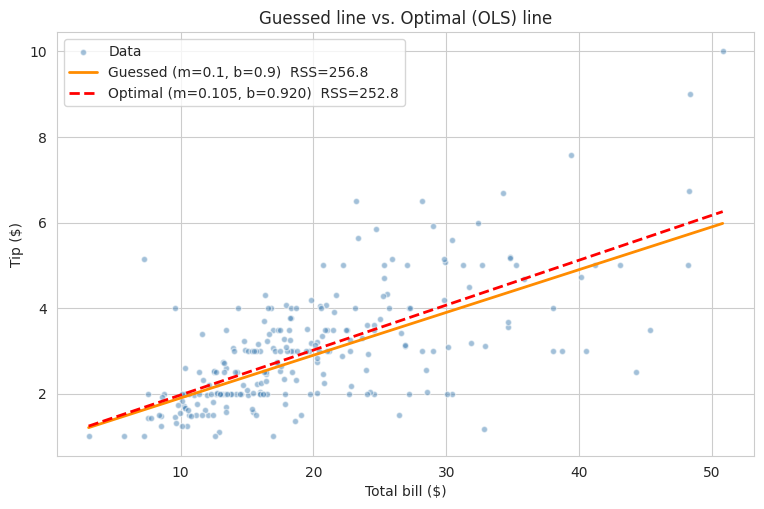

In [29]:
# @title Execute to see solution

print('''
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x, y, s=20, alpha=0.5, color='steelblue', edgecolor='white', label='Data')

x_line = np.linspace(x.min(), x.max(), 200)

ax.plot(x_line, m_guess * x_line + b_guess,
        color='darkorange', linewidth=2,
        label=f'Guessed (m={m_guess}, b={b_guess})  RSS={rss_guess:.1f}')

ax.plot(x_line, m_optimal * x_line + b_optimal,
        color='red', linewidth=2, linestyle='--',
        label=f'Optimal (m={m_optimal:.3f}, b={b_optimal:.3f})  RSS={rss_optimal:.1f}')

ax.set_xlabel('Total bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_title('Guessed line vs. Optimal (OLS) line')
ax.legend()
plt.show()
''')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(x, y, s=20, alpha=0.5, color='steelblue', edgecolor='white', label='Data')

x_line = np.linspace(x.min(), x.max(), 200)

ax.plot(x_line, m_guess * x_line + b_guess,
        color='darkorange', linewidth=2,
        label=f'Guessed (m={m_guess}, b={b_guess})  RSS={rss_guess:.1f}')

ax.plot(x_line, m_optimal * x_line + b_optimal,
        color='red', linewidth=2, linestyle='--',
        label=f'Optimal (m={m_optimal:.3f}, b={b_optimal:.3f})  RSS={rss_optimal:.1f}')

ax.set_xlabel('Total bill ($)')
ax.set_ylabel('Tip ($)')
ax.set_title('Guessed line vs. Optimal (OLS) line')
ax.legend()
plt.show()

**Question 6e (written, no code):**

1. Complete: *"Our regression model (using bill amount) explains **\_\_\_**% of the baseline variance in tip amounts."*

2. The Ames Housing model in Notebook 17_0_5 had $R^2 \approx 0.50$. How does your tips $R^2$ compare? What does this suggest about how predictable tipping is versus house prices from a single feature?

3. What other variables in the `tips` dataset (party size, day of week, smoker status) might improve the model's $R^2$ if added as predictors?

---

## Summary

Everything you built from scratch in these exercises:

| Quantity | Formula | Exercise |
|---|---|---|
| Mean | $\bar{y} = \sum y_i / N$ | 1a |
| TSS | $\sum (y_i - \bar{y})^2$ | 1b |
| Standard deviation | $\sigma_y = \sqrt{\text{TSS}/N}$ | 1c |
| Covariance | $\frac{1}{N}\sum (x_i-\bar{x})(y_i-\bar{y})$ | 3a |
| Pearson's r | $r = \text{Cov}(x,y) \,/\, (\sigma_x \sigma_y)$ | 4 |
| Residuals | $e_i = y_i - \hat{y}_i$ | 5a |
| RSS | $\sum (y_i - \hat{y}_i)^2$ | 5b, 6b |
| Optimal slope | $m^* = r \cdot \sigma_y / \sigma_x$ | 6a |
| $R^2$ | $1 - \text{RSS}/\text{TSS}$ | 6b |

Key lessons demonstrated:
- **Covariance is unit-dependent** — it changes 100× when bills are converted from dollars to cents (Exercise 3b).
- **Pearson's r is unit-invariant** — the same conversion leaves r unchanged (Exercise 4).
- **"Residuals sum to zero" is meaningless** — a backwards model with negative slope achieves it trivially (Exercise 5b).
- **sklearn matches the closed-form formula exactly** — `LinearRegression` is just an efficient implementation of what you built by hand (Exercise 6c).

---
# Exercise 7 — Negative Correlation: Weight vs. MPG

> **Why this exercise?** Exercises 1–6 used the `tips` dataset, where every interesting correlation was *positive*. The formulas for r, optimal slope, and R² work identically for negative relationships — but the sign of the slope flips. This exercise lets you verify that for yourself.

**Dataset:** `seaborn.load_dataset('mpg')` — `weight` (lbs) predicts `mpg`.
**Expected outcome:** r is strongly negative (heavier cars get worse mileage), so the optimal slope is negative.

In [30]:
import seaborn as sns, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

mpg7 = sns.load_dataset('mpg').dropna().reset_index(drop=True)
x7 = mpg7['weight'].to_numpy(dtype=float)
y7 = mpg7['mpg'].to_numpy(dtype=float)
n7 = len(x7)
print(f'n = {n7}  |  weight range: {x7.min():.0f}–{x7.max():.0f} lbs')

n = 392  |  weight range: 1613–5140 lbs


## 7a. Summary Statistics

Compute the means and standard deviations of `x7` (weight) and `y7` (mpg).

In [31]:
# ── Task 7a: ────────────────────────────────────────────────────────────────
# Fill in your code, then uncomment the print lines below to check your work.
# Compute the mean and std of x7 (weight) and y7 (mpg).
# TODO: your code here

# print(f'mean(weight) = {mean_x7:.1f} lbs   std(weight) = {std_x7:.1f}')
# print(f'mean(mpg)    = {mean_y7:.2f}        std(mpg)    = {std_y7:.2f}')

In [32]:
# @title Execute to see solution
print("""
mean_x7 = x7.mean()
mean_y7 = y7.mean()
std_x7  = x7.std()
std_y7  = y7.std()
""")
mean_x7 = x7.mean()
mean_y7 = y7.mean()
std_x7  = x7.std()
std_y7  = y7.std()
print(f'mean(weight) = {mean_x7:.1f} lbs   std(weight) = {std_x7:.1f}')
print(f'mean(mpg)    = {mean_y7:.2f}        std(mpg)    = {std_y7:.2f}')


mean_x7 = x7.mean()
mean_y7 = y7.mean()
std_x7  = x7.std()
std_y7  = y7.std()

mean(weight) = 2977.6 lbs   std(weight) = 848.3
mean(mpg)    = 23.45        std(mpg)    = 7.80


## 7b. Covariance from Scratch

Use the deviation-product formula: $\text{Cov}(x,y) = \frac{1}{n}\sum (x_i - \bar{x})(y_i - \bar{y})$.

In [33]:
# ── Task 7b: ────────────────────────────────────────────────────────────────
# Fill in your code, then uncomment the print lines below to check your work.
# Compute covariance: Cov(x,y) = mean of (x_i - x̄)(y_i - ȳ)
# Compute x7_dev (deviations of x7 from mean_x7), y7_dev, then cov_xy7.
# TODO: your code here

# print(f'Cov(weight, mpg) = {cov_xy7:.4f}')
# print(f'Sign: {"negative — heavier cars get worse mileage" if cov_xy7 < 0 else "positive"}')

In [34]:
# @title Execute to see solution
print("""
x7_dev  = x7 - mean_x7
y7_dev  = y7 - mean_y7
cov_xy7 = (x7_dev * y7_dev).mean()
""")
x7_dev  = x7 - mean_x7
y7_dev  = y7 - mean_y7
cov_xy7 = (x7_dev * y7_dev).mean()
print(f'Cov(weight, mpg) = {cov_xy7:.4f}')
print(f'Sign: {"negative — heavier cars get worse mileage" if cov_xy7 < 0 else "positive"}')


x7_dev  = x7 - mean_x7
y7_dev  = y7 - mean_y7
cov_xy7 = (x7_dev * y7_dev).mean()

Cov(weight, mpg) = -5503.3656
Sign: negative — heavier cars get worse mileage


## 7c. Pearson's r

Divide covariance by the product of standard deviations: $r = \text{Cov}(x,y) / (\sigma_x \cdot \sigma_y)$.

In [35]:
# ── Task 7c: ────────────────────────────────────────────────────────────────
# Fill in your code, then uncomment the print lines below to check your work.
# Compute Pearson's r: r = Cov(x,y) / (std_x * std_y)
# TODO: your code here

# print(f'r = {r7:.4f}')
# print(f'|r| = {abs(r7):.4f} — {"strong" if abs(r7) > 0.7 else "moderate"} {"negative" if r7 < 0 else "positive"} association')

In [36]:
# @title Execute to see solution
print("""
r7 = cov_xy7 / (std_x7 * std_y7)
""")
r7 = cov_xy7 / (std_x7 * std_y7)
print(f'r = {r7:.4f}')
print(f'|r| = {abs(r7):.4f} — {"strong" if abs(r7) > 0.7 else "moderate"} {"negative" if r7 < 0 else "positive"} association')


r7 = cov_xy7 / (std_x7 * std_y7)

r = -0.8322
|r| = 0.8322 — strong negative association


## 7d. Optimal Slope and Intercept

Use the closed-form OLS formulas: $m = r \cdot \sigma_y / \sigma_x$ and $b = \bar{y} - m \cdot \bar{x}$.

In [37]:
# ── Task 7d: ────────────────────────────────────────────────────────────────
# Fill in your code, then uncomment the print lines below to check your work.
# Compute the OLS slope and intercept.
# m = r * (std_y / std_x)    b = mean_y - m * mean_x
# TODO: your code here

# print(f'Optimal slope:     {m7:.6f}  (mpg per lb)')
# print(f'Optimal intercept: {b7:.4f}')
# print(f'\nInterpretation: each additional 1,000 lbs → {m7 * 1000:.2f} mpg change')

In [38]:
# @title Execute to see solution
print("""
m7 = r7 * (std_y7 / std_x7)
b7 = mean_y7 - m7 * mean_x7
""")
m7 = r7 * (std_y7 / std_x7)
b7 = mean_y7 - m7 * mean_x7
print(f'Optimal slope:     {m7:.6f}  (mpg per lb)')
print(f'Optimal intercept: {b7:.4f}')
print(f'Interpretation: each additional 1,000 lbs → {m7 * 1000:.2f} mpg change')


m7 = r7 * (std_y7 / std_x7)
b7 = mean_y7 - m7 * mean_x7

Optimal slope:     -0.007647  (mpg per lb)
Optimal intercept: 46.2165
Interpretation: each additional 1,000 lbs → -7.65 mpg change


## 7e. RSS and R²

Compute the fitted values, then RSS and R². Verify $R^2 = r^2$.

In [39]:
# ── Task 7e: ────────────────────────────────────────────────────────────────
# Fill in your code, then uncomment the print lines below to check your work.
# Compute fitted values, residuals, RSS, TSS, and R².
# y_hat = m*x + b  |  resid = y - y_hat  |  RSS = sum(resid²)
# TSS = sum((y - mean_y)²)  |  R² = 1 - RSS/TSS
# TODO: your code here

# print(f'RSS = {rss7:.2f}')
# print(f'R²  = {r2_7:.4f}')
# print(f'r²  = {r7**2:.4f}  (should match R²)')

In [40]:
# @title Execute to see solution
print("""
y7_hat = m7 * x7 + b7
resid7 = y7 - y7_hat
rss7   = (resid7 ** 2).sum()
tss7   = ((y7 - mean_y7) ** 2).sum()
r2_7   = 1 - rss7 / tss7
""")
y7_hat = m7 * x7 + b7
resid7 = y7 - y7_hat
rss7   = (resid7 ** 2).sum()
tss7   = ((y7 - mean_y7) ** 2).sum()
r2_7   = 1 - rss7 / tss7
print(f'RSS = {rss7:.2f}')
print(f'R²  = {r2_7:.4f}')
print(f'r²  = {r7**2:.4f}  (should match R²)')


y7_hat = m7 * x7 + b7
resid7 = y7 - y7_hat
rss7   = (resid7 ** 2).sum()
tss7   = ((y7 - mean_y7) ** 2).sum()
r2_7   = 1 - rss7 / tss7

RSS = 7321.23
R²  = 0.6926
r²  = 0.6926  (should match R²)


## 7f. Plot + sklearn Verification

Visualize the fitted line and verify with sklearn.

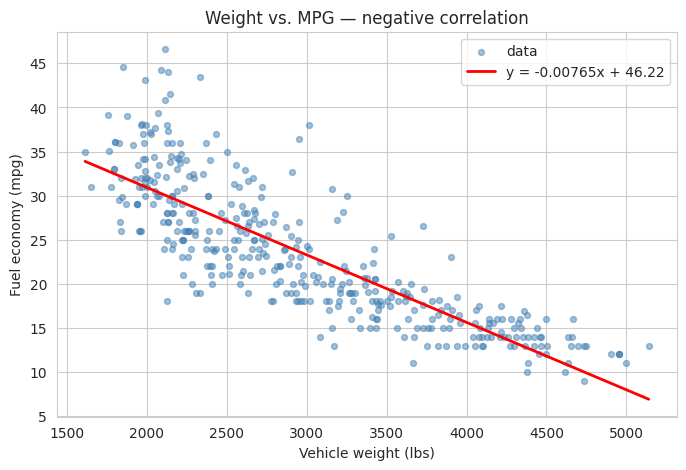

Scratch slope:  -0.007647   sklearn: -0.007647
Scratch intercept: 46.2165   sklearn: 46.2165
Scratch R²:  0.6926   sklearn: 0.6926


In [41]:
# Given — plot and verify
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x7, y7, s=18, alpha=0.5, color='steelblue', label='data')
x7_line = np.linspace(x7.min(), x7.max(), 200)
ax.plot(x7_line, m7 * x7_line + b7, color='red', linewidth=2, label=f'y = {m7:.5f}x + {b7:.2f}')
ax.set_xlabel('Vehicle weight (lbs)')
ax.set_ylabel('Fuel economy (mpg)')
ax.set_title('Weight vs. MPG — negative correlation')
ax.legend()
plt.show()

sk = LinearRegression().fit(x7.reshape(-1, 1), y7)
print(f'Scratch slope:  {m7:.6f}   sklearn: {sk.coef_[0]:.6f}')
print(f'Scratch intercept: {b7:.4f}   sklearn: {sk.intercept_:.4f}')
print(f'Scratch R²:  {r2_7:.4f}   sklearn: {sk.score(x7.reshape(-1,1), y7):.4f}')